# Single-trip delay analysis

Drill into individual trips. Runs the segment delay breakdown (MIT thesis §3.3) across all service dates for one shape, then plots a chosen trip's distance- and speed-over-time through a segment with stopping activities colored by delay type (dwell / uniform / overflow / congestion), plus one example trip per delay flavor. All calculations live in `segment_delay.py`.

In [1]:
import geopandas as gpd
import pandas as pd
from IPython.display import display

from constants import CA_NAD83_Albers, CULVER_CITY_FEED_KEY, SERVICE_DATE, SHAPE_KEY_TO_SHAPE_ID_MAP
from _data_loaders import (
    get_culver_city_vehicle_positions,
    get_selected_shapes,
    get_traffic_signals,
    list_available_service_dates,
)
from segment_delay import run_segment_delay_analysis

## Configuration

In [2]:
SHAPE_KEY = "105"
SHAPE_ID = SHAPE_KEY_TO_SHAPE_ID_MAP[SHAPE_KEY]
print(f"Shape: {SHAPE_KEY} -> {SHAPE_ID}")

Shape: 105 -> shp-1-05


## Load inputs

All trips for the shape across every service date, plus the shape geometry, signals, and stops (with hand-curated near-side flags). Loading all dates reads every per-date geoparquet, so this cell is the slow one.

In [3]:
service_dates = list_available_service_dates()
vehicle_positions = pd.concat(
    [
        get_culver_city_vehicle_positions([SHAPE_KEY], service_date).assign(service_date=service_date)
        for service_date in service_dates
    ],
    ignore_index=True,
)
print(f"{len(vehicle_positions):,} positions over {len(service_dates)} dates")

shapes = get_selected_shapes(SERVICE_DATE, CULVER_CITY_FEED_KEY, [SHAPE_ID])
signals = get_traffic_signals()
stops = gpd.read_file(f"data/stops_{SHAPE_ID}.geojson").to_crs(CA_NAD83_Albers)

293,339 positions over 22 dates


## Run the breakdown

In [4]:
result = run_segment_delay_analysis(vehicle_positions, shapes, signals, stops, SHAPE_ID)
print(f"{len(result.segments)} analyzed segments (between signals, not ending at a near-side signal)")
result.segments.round(1)

44 analyzed segments (between signals, not ending at a near-side signal)


,start_signal,end_signal,start_distance_m,end_distance_m,length_m
segment_id,,,,,
sig1_to_sig2,1,2,27.5,386.5,359.0
sig2_to_sig3,2,3,386.5,517.1,130.5
sig3_to_sig4,3,4,517.1,981.9,464.8
sig4_to_sig5,4,5,981.9,1030.1,48.2
sig5_to_sig6,5,6,1030.1,1236.4,206.4
sig6_to_sig7,6,7,1236.4,1494.1,257.7
sig7_to_sig8,7,8,1494.1,1694.7,200.6
sig8_to_sig9,8,9,1694.7,1803.6,108.9
sig9_to_sig10,9,10,1803.6,2010.9,207.3


## Single trip through a segment

Plot one trip's distance-over-time and speed-over-time through a chosen segment, with stopping activities shaded by how they were coded: **dwell** (gray), **uniform** signal delay (blue), **overflow** (purple), **congestion** (orange).

In [5]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from segment_delay import DELAY_TYPE_COLORS, analyze_trip_segment, example_trip_segments

M_PER_S_TO_MPH = 2.236936


def plot_trip_segment(detail, title=None):
    """Distance- and speed-over-time for one trip in a segment.

    Black line = smoothed trajectory; red dots (distance plot) = raw projected
    GPS pings; shaded bands = stopping activities colored by delay type.
    """
    segment_entry_time = detail.segment_trajectory.index[0]
    elapsed_s = (detail.segment_trajectory.index - segment_entry_time).total_seconds()
    distance_into_segment_m = detail.segment_trajectory.to_numpy() - detail.segment["start_distance_m"]
    speed_mph = detail.segment_speeds.to_numpy() * M_PER_S_TO_MPH

    fig, (ax_distance, ax_speed) = plt.subplots(2, 1, sharex=True, figsize=(11, 7))
    ax_distance.plot(elapsed_s, distance_into_segment_m, color="black", lw=1.5, zorder=2)
    ax_speed.plot(elapsed_s, speed_mph, color="black", lw=1.5, zorder=2)

    # Raw projected GPS pings overlaid on the distance plot.
    raw_points = detail.trip_positions
    has_raw = len(raw_points) > 0
    if has_raw:
        raw_elapsed_s = (raw_points.index - segment_entry_time).total_seconds()
        ax_distance.scatter(
            raw_elapsed_s, raw_points.to_numpy() - detail.segment["start_distance_m"],
            s=16, color="tab:red", alpha=0.6, zorder=3,
        )

    present_types = set()
    for stop in detail.stops.itertuples():
        stop_start_s = (stop.start_timestamp - segment_entry_time).total_seconds()
        stop_end_s = (stop.end_timestamp - segment_entry_time).total_seconds()
        color = DELAY_TYPE_COLORS.get(stop.delay_type, "tab:gray")
        for ax in (ax_distance, ax_speed):
            ax.axvspan(stop_start_s, stop_end_s, color=color, alpha=0.35)
        present_types.add(stop.delay_type)

    ax_distance.set_ylabel("distance into segment (m)")
    ax_speed.set_ylabel("speed (mph)")
    ax_speed.set_xlabel("seconds since entering segment")
    ax_distance.set_title(title or str(detail.segment.name))

    legend_handles = [Line2D([0], [0], color="black", lw=1.5, label="smoothed")]
    if has_raw:
        legend_handles.append(
            Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="tab:red",
                   markeredgecolor="none", alpha=0.6, label="GPS pings")
        )
    legend_handles += [
        mpatches.Patch(color=DELAY_TYPE_COLORS[delay_type], alpha=0.35, label=delay_type)
        for delay_type in DELAY_TYPE_COLORS
        if delay_type in present_types
    ]
    ax_distance.legend(handles=legend_handles, loc="upper left", fontsize=8)
    fig.tight_layout()
    return fig

### Pick a segment and trip

Set `SEGMENT_ID`; the table lists the daytime trips through it (highest total delay first) so you can choose a `service_date` / `TRIP_KEY` to plot.

,service_date,TRIP_KEY,observed_travel_time_s,uniform_delay_s,overflow_delay_s,congestion_delay_s,total_delay_s
5405,2026-02-02,748.0,254.5,0.0,0.0,213.5,213.5
23708,2026-02-11,943.0,250.6,0.0,0.0,209.6,209.6
23314,2026-02-11,62.0,245.5,0.0,0.0,204.5,204.5
19539,2026-02-10,1041.0,218.9,0.0,0.0,178.0,178.0
32397,2026-02-16,62.0,213.5,0.0,0.0,172.5,172.5
13230,2026-02-06,231.0,211.4,0.0,0.0,170.5,170.5
27326,2026-02-13,631.0,210.0,0.0,0.0,169.1,169.1
30145,2026-02-15,1425.0,202.1,0.0,0.0,161.1,161.1
1671,2026-01-31,723.0,200.8,0.0,0.0,159.9,159.9
18267,2026-02-09,1469.0,193.3,0.0,0.0,152.3,152.3


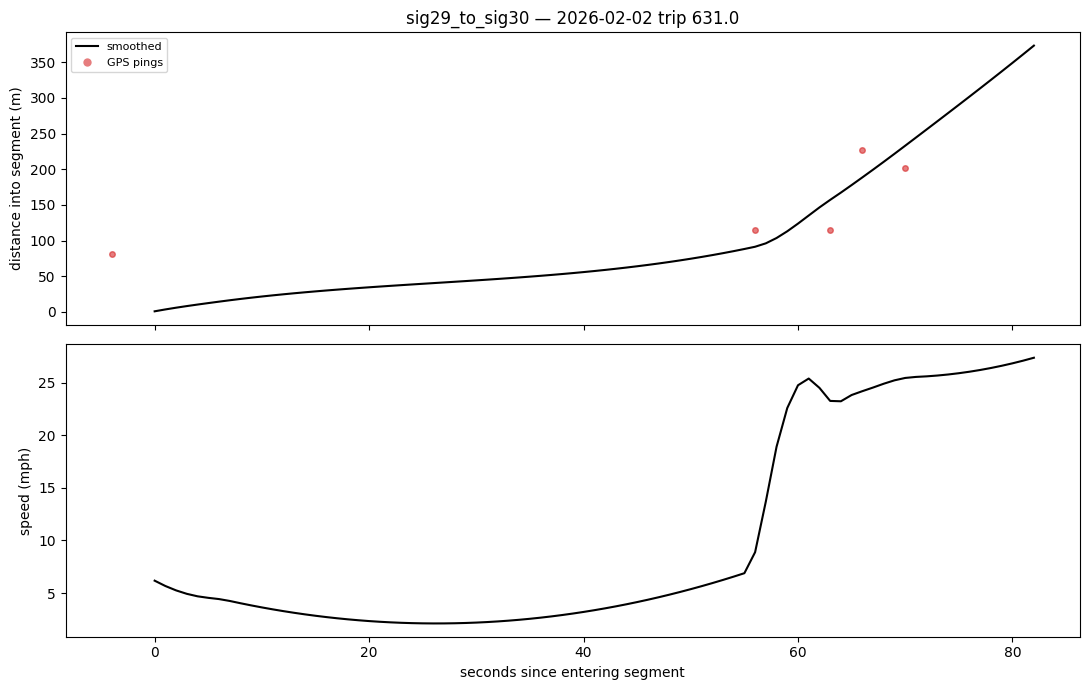

In [6]:
SEGMENT_ID = "sig29_to_sig30"

segment_trips = (
    result.daytime_delays[result.daytime_delays["segment_id"] == SEGMENT_ID][
        ["service_date", "TRIP_KEY", "observed_travel_time_s",
         "uniform_delay_s", "overflow_delay_s", "congestion_delay_s", "total_delay_s"]
    ]
    .sort_values("total_delay_s", ascending=False)
)
display(segment_trips.head(10).round(1))

# Pick one (defaults to the most-delayed trip; edit these to choose another row).
SELECTED_SERVICE_DATE = segment_trips.iloc[0]["service_date"]
SELECTED_TRIP_KEY = segment_trips.iloc[6]["TRIP_KEY"]

detail = analyze_trip_segment(
    vehicle_positions, shapes, signals, stops, SHAPE_ID,
    SELECTED_SERVICE_DATE, SELECTED_TRIP_KEY, SEGMENT_ID,
)
plot_trip_segment(detail, title=f"{SEGMENT_ID} — {SELECTED_SERVICE_DATE} trip {SELECTED_TRIP_KEY}")
plt.show()

### Example of each delay type

One representative trip with **uniform signal delay**, one with **overflow delay**, and one with **congestion only** (each may be on a different segment).

,example,service_date,TRIP_KEY,segment_id,uniform_delay_s,overflow_delay_s,signal_delay_s,congestion_delay_s
0,signal (uniform),2026-02-07,719.0,sig45_to_sig46,343.0,0.0,343.0,21.3
1,overflow,2026-02-08,273.0,sig15_to_sig16,35.3,168.7,204.0,0.0
2,congestion,2026-02-13,1376.0,sig40_to_sig41,0.0,0.0,0.0,1735.0


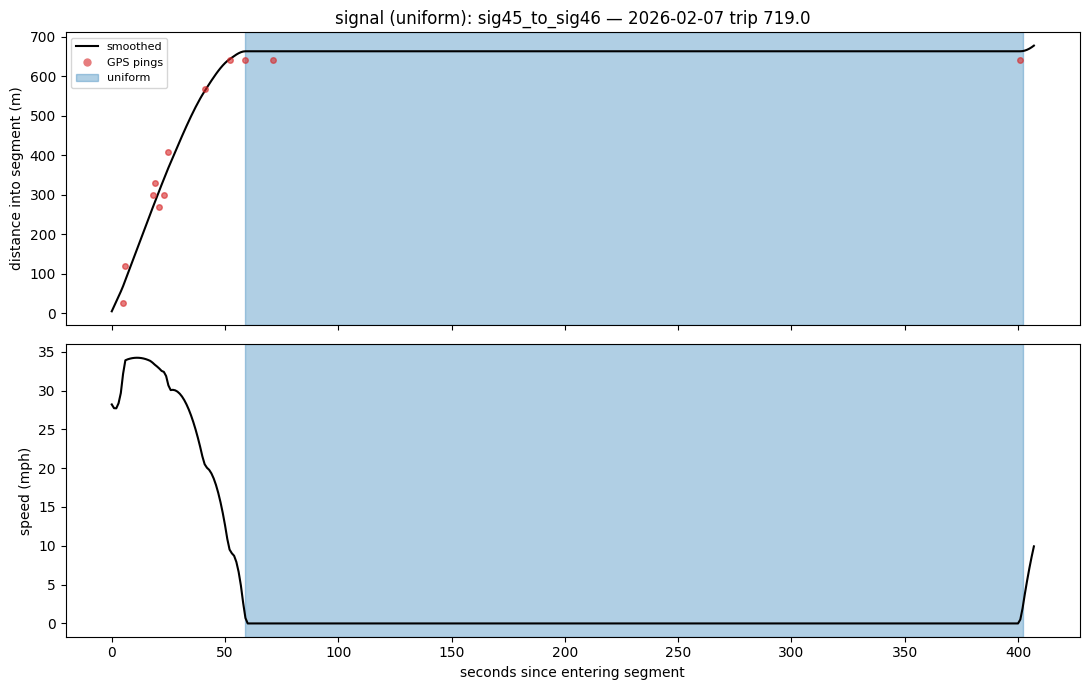

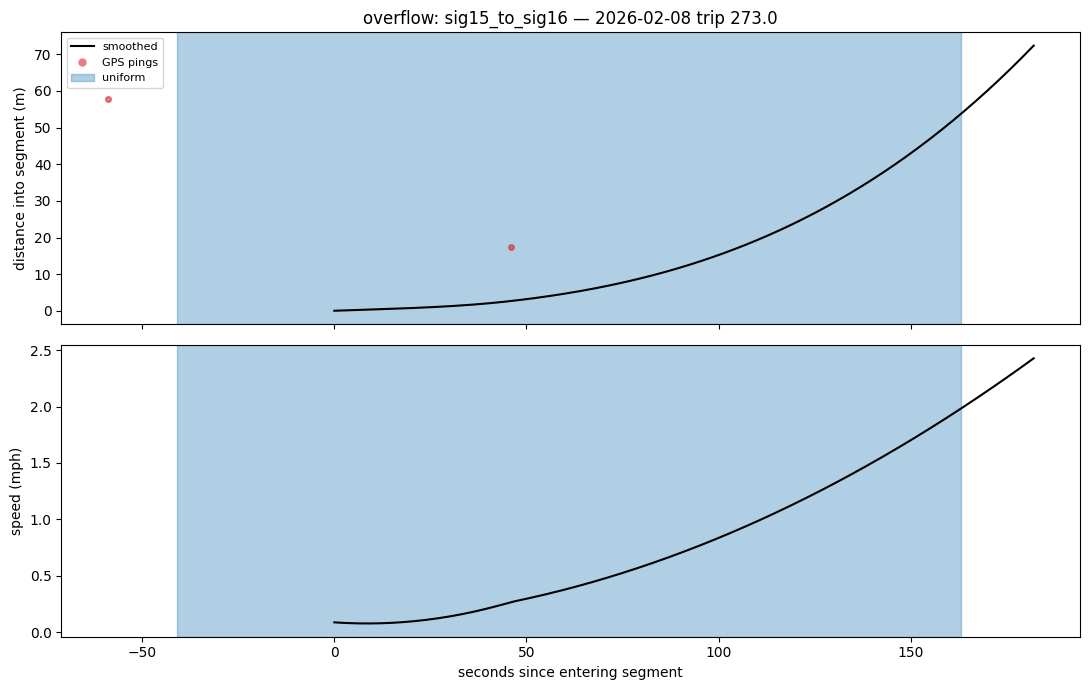

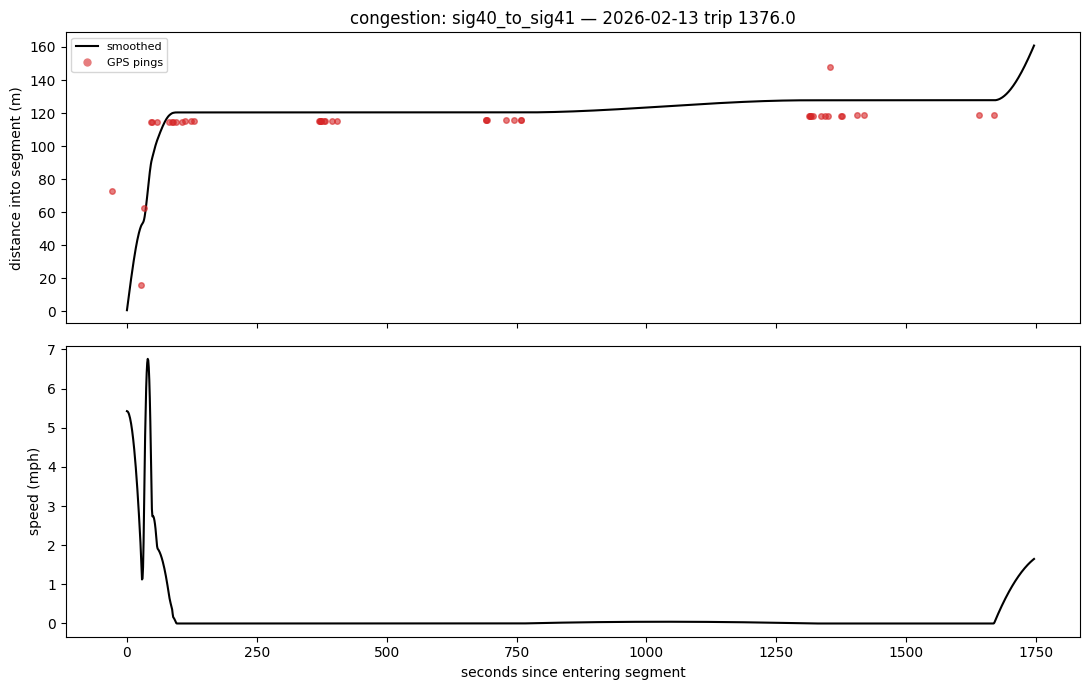

In [7]:
examples = example_trip_segments(result.daytime_delays)
display(examples.round(1))

for example in examples.itertuples():
    example_detail = analyze_trip_segment(
        vehicle_positions, shapes, signals, stops, SHAPE_ID,
        example.service_date, example.TRIP_KEY, example.segment_id,
    )
    plot_trip_segment(
        example_detail,
        title=f"{example.example}: {example.segment_id} — {example.service_date} trip {example.TRIP_KEY}",
    )
    plt.show()